## cleaning the bank marketing dataset

In [1]:
## load in the whole dataset

import pandas as pd
from itables import show

df = pd.read_csv('../data/bank-full.csv', sep=';')

show(df)

Loading ITables v2.7.1 from the internet... (need help?)


In [2]:
## check the headers and make sure they are clean
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [3]:
## check for all the ages

df['age'].dtype

dtype('int64')

In [4]:
## check if there is any customer with unkown contact

df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [5]:
### check if this unkown contacts agreed to subscribe
unknown_contact = df[df['contact'] == 'unknown']

print(unknown_contact['y'].value_counts())

y
no     12490
yes      530
Name: count, dtype: int64


In [6]:
## compare value of contacts by subscription

df.groupby('contact')['y'].value_counts(normalize=True).unstack() * 100

y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


In [7]:
## Answering the first question how many customers said yes to subscription and how many said no

subscription_count = df['y'].value_counts()
subscription_count

y
no     39922
yes     5289
Name: count, dtype: int64

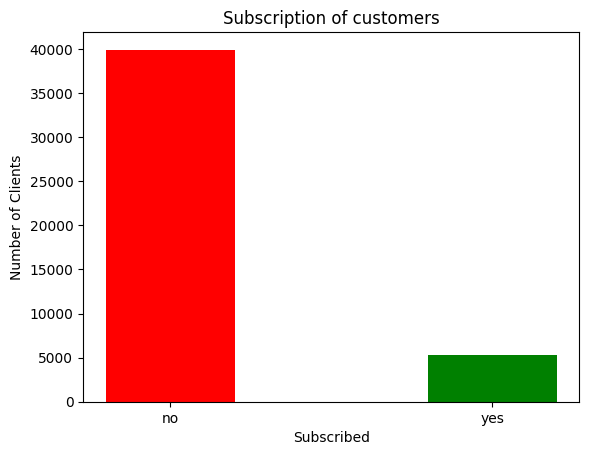

In [8]:
## show subscription in a bar graph

import matplotlib.pyplot as plt

plt.bar(['no','yes'], subscription_count.values, color=['red','green'], width=0.4)
plt.title('Subscription of customers')
plt.xlabel('Subscribed')
plt.ylabel('Number of Clients')
plt.show()

In [ ]:
## find out the average age of customers being reached and if age play a role in whether someone subscribes

average_age = df['age'].mean()
min_age = df['age'].min()
oldest_age = df['age'].max()
median_age = df['age'].median()

print(f'average age is {average_age}')
print(f'Minimun age reached out to is {min_age}')
print(f'Oldest person reached out to is {oldest_age} years old')
print(f'Median age is {median_age}')

# average age if someone subscribe or not

age_by_subscription = df.groupby('y')['age'].mean()
print(age_by_subscription)

average age is 40.93621021432837
Minimun age reached out to is 18
Oldest person reached out to is 95 years old
Median age is 39.0
y
no     40.838986
yes    41.670070
Name: age, dtype: float64


check for subscription by age and break the age into like age groups

In [20]:
# break age into groups

bins = [1,25,35,45,55,65,100]
labels = ['under 25','25-34','35-44','45-54','55-64','65+']

df['age_group'] = pd.cut(df['age'], bins = bins, labels=labels)

# Subscription rate per age group
age_group_rate = df.groupby('age_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) *100).reset_index()

age_group_rate.columns = ['age_group','subscription_rate']
print(age_group_rate)

  age_group  subscription_rate
0  under 25          23.952096
1     25-34          12.003083
2     35-44           9.389434
3     45-54           9.352744
4     55-64          14.123885
5       65+          42.609854


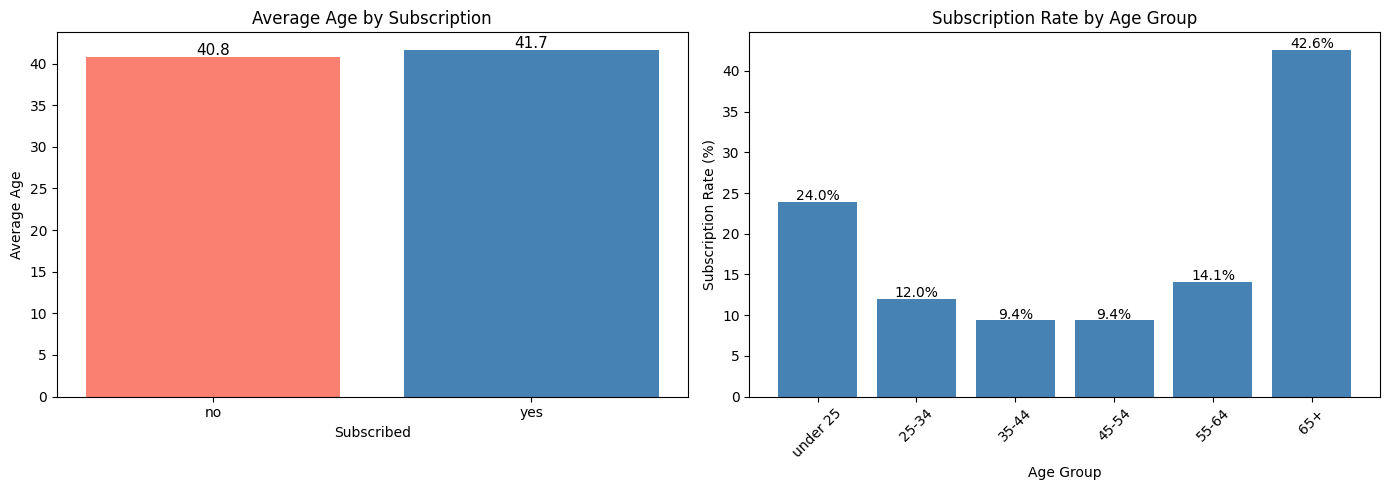

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Average age yes vs no
axes[0].bar(age_by_subscription.index,
            age_by_subscription.values,
            color=['salmon', 'steelblue'])
axes[0].set_title('Average Age by Subscription')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Average Age')
for i, v in enumerate(age_by_subscription.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=11)

# Chart 2 - Subscription rate by age group
axes[1].bar(age_group_rate['age_group'],
            age_group_rate['subscription_rate'],
            color='steelblue')
axes[1].set_title('Subscription Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_group_rate['subscription_rate']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
print("=== FINDING ===")
print(f"Average age of subscribers:     {df[df['y']=='yes']['age'].mean():.1f} years")
print(f"Average age of non-subscribers: {df[df['y']=='no']['age'].mean():.1f} years")
print(f"Age group with highest subscription rate: {age_group_rate.loc[age_group_rate['subscription_rate'].idxmax(), 'age_group']}")
print(f"Subscription rate for that group: {age_group_rate['subscription_rate'].max():.1f}%")

=== FINDING ===
Average age of subscribers:     41.7 years
Average age of non-subscribers: 40.8 years
Age group with highest subscription rate: 65+
Subscription rate for that group: 42.6%


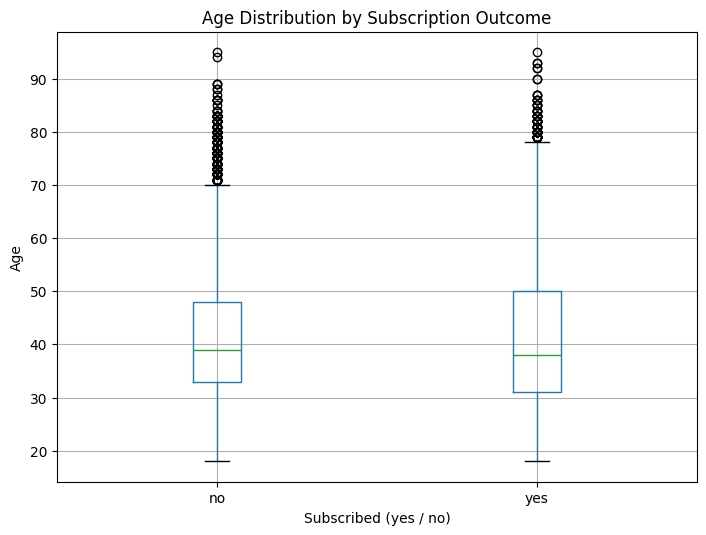

In [11]:
df.boxplot(column='age', by='y', figsize=(8, 6))


plt.title('Age Distribution by Subscription Outcome')
plt.suptitle('')
plt.xlabel('Subscribed (yes / no)')
plt.ylabel('Age')
plt.show()

In [16]:
## Percentage of customers who said yes to those who said no

df.head()

sub_percentage = df['y'].value_counts(normalize=True) * 100
print(sub_percentage.round(2).astype(str) + '%')


y
no     88.3%
yes    11.7%
Name: proportion, dtype: str


#### Job types that make majority of the customer base, and which job types are most likely to subscribe 

In [ ]:
## all job types
majority_job_sub = df['job'].value_counts()
majority_job_sub

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [24]:
## all job_types and subscription

subscribers_by_job = df[df['y'] == 'yes']['job'].value_counts()
subscribers_by_job

job
management       1301
technician        840
blue-collar       708
admin.            631
retired           516
services          369
student           269
unemployed        202
self-employed     187
entrepreneur      123
housemaid         109
unknown            34
Name: count, dtype: int64